# PyTrebuchet: Optimize release angle of a trebuchet

This notebook creates a plot showing the relation between release angle and the projectile range of the trebuchet.
Next, it finds the optimal release angle that maximizes the distance traveled by the projectile.

## 1. setup + plot distance traveled in function of the release angle

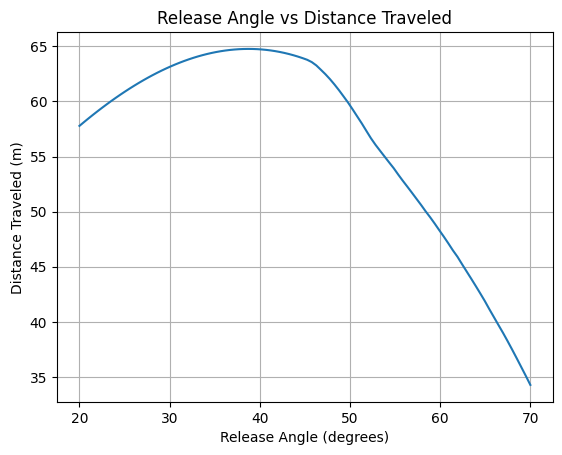

In [1]:
import sys

sys.path.insert(0, "../src")
from pytrebuchet import Trebuchet, Projectile, Simulation
import numpy as np
import matplotlib.pyplot as plt

# Release angles to test (in degrees) + distances array
release_angles = np.linspace(20, 70, 100)
distances = []

# Simulate for each release angle
trebuchet = Trebuchet.default_hcw()
projectile = Projectile.default()

for release_angle in release_angles:
    trebuchet.release_angle = release_angle * np.pi / 180.0

    simulation = Simulation(trebuchet, projectile)
    simulation.solve()

    distances.append(simulation.distance_traveled)

# Plotting the results
fig, ax = plt.subplots()
ax.plot(release_angles, distances)
ax.set_xlabel("Release Angle (degrees)")
ax.set_ylabel("Distance Traveled (m)")
ax.set_title("Release Angle vs Distance Traveled")
plt.grid()
plt.show()

## 2. Find the optimal release angle

In [2]:
from scipy.optimize import minimize_scalar


# Function to minimize (negative distance traveled)
def negative_distance(release_angle):
    trebuchet.release_angle = release_angle * np.pi / 180.0
    simulation = Simulation(trebuchet, projectile)
    simulation.solve()

    return -simulation.distance_traveled


# Find the optimal release angle
result = minimize_scalar(negative_distance, bounds=(20, 70), method="bounded")
print(f"Optimal release angle: {result.x:.2f} degrees")
print(f"Maximum distance traveled: {-result.fun:.2f} meters")

Optimal release angle: 38.74 degrees
Maximum distance traveled: 64.77 meters
